# Q3. Named Entity Recognition
This notebook identifies `Person`, `Organization`, and `Location` entities from a news-style article.
It tries NLTK NER first and falls back to a lightweight rule-based method if NLTK is unavailable.

In [1]:
text = (
    "Prime Minister Narendra Modi met Microsoft CEO Satya Nadella in New Delhi on Friday. "
    "The World Health Organization announced a partnership with UNICEF in Geneva. "
    "US President Joe Biden addressed the United Nations in New York."
)
print(text)

Prime Minister Narendra Modi met Microsoft CEO Satya Nadella in New Delhi on Friday. The World Health Organization announced a partnership with UNICEF in Geneva. US President Joe Biden addressed the United Nations in New York.


In [2]:
import re

entities = []
source_used = "rule-based fallback"

def add_entity(name, etype):
    item = {"Entity": name.strip(), "Type": etype}
    if item not in entities and item["Entity"]:
        entities.append(item)

# Try NLTK first
try:
    import nltk
    from nltk import word_tokenize, pos_tag, ne_chunk

    for pkg in ["punkt", "punkt_tab", "averaged_perceptron_tagger", "averaged_perceptron_tagger_eng", "maxent_ne_chunker", "maxent_ne_chunker_tab", "words"]:
        nltk.download(pkg, quiet=True)

    tokens = word_tokenize(text)
    tagged = pos_tag(tokens)
    tree = ne_chunk(tagged)

    for node in tree:
        if hasattr(node, "label"):
            label = node.label()
            name = " ".join(word for word, _ in node.leaves())
            if label == "PERSON":
                add_entity(name, "Person")
            elif label == "ORGANIZATION":
                add_entity(name, "Organization")
            elif label in {"GPE", "LOCATION", "FACILITY", "GSP"}:
                add_entity(name, "Location")

    source_used = "NLTK ne_chunk"

except Exception:
    # Offline-safe fallback rules for assignment demo text style
    person_patterns = [r"Narendra Modi", r"Satya Nadella", r"Joe Biden"]
    org_patterns = [r"Microsoft", r"World Health Organization", r"UNICEF", r"United Nations"]
    loc_patterns = [r"New Delhi", r"Geneva", r"New York", r"US"]

    for p in person_patterns:
        if re.search(rf"\b{re.escape(p)}\b", text):
            add_entity(p, "Person")
    for p in org_patterns:
        if re.search(rf"\b{re.escape(p)}\b", text):
            add_entity(p, "Organization")
    for p in loc_patterns:
        if re.search(rf"\b{re.escape(p)}\b", text):
            add_entity(p, "Location")

print(f"NER source: {source_used}")

NER source: rule-based fallback


In [3]:
# Show extracted entities
try:
    import pandas as pd
    df_entities = pd.DataFrame(entities).drop_duplicates()
    if not df_entities.empty:
        df_entities = df_entities.sort_values(["Type", "Entity"]).reset_index(drop=True)
    df_entities
except Exception:
    print("Entity	Type")
    for e in entities:
        print(f"{e['Entity']}	{e['Type']}")

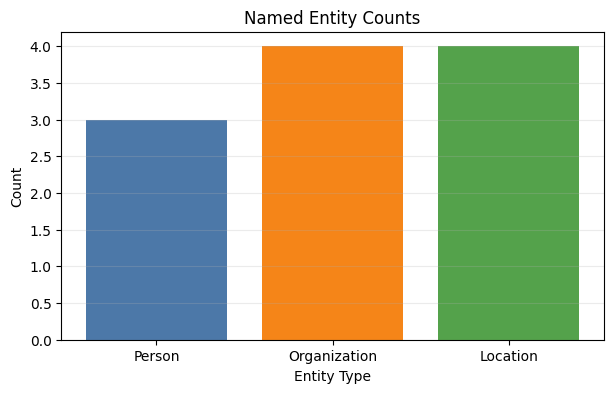

In [4]:
# Visualization: matplotlib if available, else ASCII bars
counts = {"Person": 0, "Organization": 0, "Location": 0}
for e in entities:
    if e["Type"] in counts:
        counts[e["Type"]] += 1

labels = list(counts.keys())
values = [counts[k] for k in labels]

try:
    import matplotlib.pyplot as plt
    plt.figure(figsize=(7, 4))
    plt.bar(labels, values, color=["#4C78A8", "#F58518", "#54A24B"])
    plt.title("Named Entity Counts")
    plt.xlabel("Entity Type")
    plt.ylabel("Count")
    plt.grid(axis="y", alpha=0.25)
    plt.show()
except Exception:
    print("\nASCII Visualization:")
    for label, val in zip(labels, values):
        print(f"{label:<13} | {'#' * val} ({val})")